In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
import tensorflow_datasets as tfds


In [3]:
# ── Config ──────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 10
NUM_CLASSES = 101
LR          = 1e-4


In [4]:
# ── Data pipeline ────────────────────────────────────────────────────────────
from tensorflow.keras.applications.efficientnet import preprocess_input
def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label


In [5]:
(ds_train, ds_val), info = tfds.load(
    'food101',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.2AT6GQ_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.2AT6GQ_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [6]:
train_ds = (ds_train
    .map(preprocess,  num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment,     num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_ds = (ds_val
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))


In [7]:
# ── Model ─────────────────────────────────────────────────────────────────────
def build_model():
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    # Phase 1: freeze base, train only the head
    base.trainable = False

    inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# ── Phase 1: Train head only (5 epochs) ──────────────────────────────────────
print("Phase 1: Training head only...")
model.fit(train_ds, validation_data=val_ds, epochs=5)

Phase 1: Training head only...
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 304s 112ms/step - accuracy: 0.2980 - loss: 3.0871 - val_accuracy: 0.5750 - val_loss: 1.6494
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 230s 95ms/step - accuracy: 0.5017 - loss: 1.9941 - val_accuracy: 0.6454 - val_loss: 1.3421
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 227s 94ms/step - accuracy: 0.5580 - loss: 1.7420 - val_accuracy: 0.6756 - val_loss: 1.2196
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 260s 93ms/step - accuracy: 0.5889 - loss: 1.6074 - val_accuracy: 0.6916 - val_loss: 1.1510
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 224s 93ms/step - accuracy: 0.6114 - loss: 1.5145 - val_accuracy: 0.7026 - val_loss: 1.1061


In [9]:
# ── Phase 2: Unfreeze top layers, fine-tune with Callbacks ───────────────────
print("Phase 2: Fine-tuning top layers...")
model.layers[1].trainable = True   # unfreeze EfficientNetB0 base
for layer in model.layers[1].layers[:-60]:
    layer.trainable = False        # keep bottom layers frozen

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR / 10),  # 10x smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Phase 2: Fine-tuning top layers...
Epoch 1/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 304s 110ms/step - accuracy: 0.4874 - loss: 2.0557 - val_accuracy: 0.6669 - val_loss: 1.2635 - learning_rate: 1.0000e-05
Epoch 2/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 231s 95ms/step - accuracy: 0.5900 - loss: 1.5953 - val_accuracy: 0.7063 - val_loss: 1.0956 - learning_rate: 1.0000e-05
Epoch 3/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 230s 95ms/step - accuracy: 0.6240 - loss: 1.4528 - val_accuracy: 0.7241 - val_loss: 1.0180 - learning_rate: 1.0000e-05
Epoch 4/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 266s 97ms/step - accuracy: 0.6433 - loss: 1.3612 - val_accuracy: 0.7360 - val_loss: 0.9702 - learning_rate: 1.0000e-05
Epoch 5/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 241s 100ms/step - accuracy: 0.6604 - loss: 1.2944 - val_accuracy: 0.7435 - val_loss: 0.9344 - learning_rate: 1.0000e-05
Epoch 6/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 232s 96ms/step - accuracy: 0.6750 - loss: 1.2380 - val_accuracy: 0.7513 - val_loss: 0.9061 - learning_rate: 1.0000e-

### 💾 Save Progress to Google Drive
Run these cells to persist your model so you don't lose progress when the runtime disconnects.

### 🔄 How to Resume Later
When you start a new session, run the setup cells (imports, config, data pipeline) and then use this code to load your saved model instead of building a new one:

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
import os

# Create the directory if it doesn't exist
os.makedirs('training', exist_ok=True)

# Save checkpoint
model.save('training/efficientnet_food_finetuned.keras')
print("Model saved.")

Model saved.


### 🚀 Test the Model

Now let's load the fine-tuned model and test its performance on a sample image.

In [14]:
import tensorflow as tf

# Load the saved model
loaded_model = tf.keras.models.load_model('training/efficientnet_food_finetuned.keras')
print("Model loaded successfully!")

Model loaded successfully!


To test the model, we need to prepare an image in the same way the training data was preprocessed:

1.  **Resize**: Resize the image to `IMG_SIZE` (224x224).
2.  **Cast**: Convert the image to `float32`.
3.  **Preprocess**: Apply the EfficientNet preprocessing function.

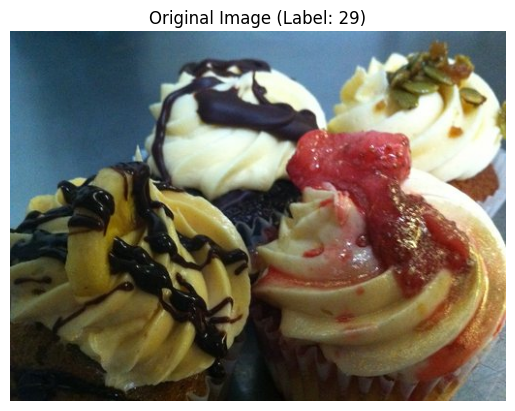

Sample image prepared for prediction.


In [12]:
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# Download a sample image (e.g., from TensorFlow Datasets food101)
# For demonstration, we'll fetch one from the validation set

# Note: This assumes ds_val is still available from earlier execution. If not, you might need to re-run data loading cells.

# Get a single image from the validation set
for image, label in ds_val.take(1):
    sample_image = image.numpy()
    sample_label = label.numpy()
    break

# Display the original image
plt.imshow(sample_image)
plt.title(f"Original Image (Label: {sample_label})") # We don't have class names yet
plt.axis('off')
plt.show()

# Preprocess the sample image for the model
processed_image = tf.image.resize(sample_image, [IMG_SIZE, IMG_SIZE])
processed_image = tf.cast(processed_image, tf.float32)
processed_image = preprocess_input(processed_image)

# The model expects a batch of images, so add a batch dimension
processed_image = np.expand_dims(processed_image, axis=0)

print("Sample image prepared for prediction.")

In [15]:
# Make a prediction
predictions = loaded_model.predict(processed_image)

# Get the predicted class (index with the highest probability)
predicted_class_index = np.argmax(predictions[0])

# Display the prediction
print(f"Predicted class index: {predicted_class_index}")
print(f"Confidence: {np.max(predictions[0]):.2f}")

# To make this more useful, we would need the class names. Let's add that for context.
# You can get class names from info.features['label'].names if 'food101' dataset is loaded.
if 'info' in globals() and hasattr(info, 'features') and 'label' in info.features:
    class_names = info.features['label'].names
    print(f"Predicted food item: {class_names[predicted_class_index]}")
else:
    print("Class names not available. Run the data loading cells if you want to see class names.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Predicted class index: 29
Confidence: 0.84
Predicted food item: cup_cakes
